In [4]:
# Cell 1: Imports and setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import random
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# ML Libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score)

# Visualization
from wordcloud import WordCloud

# Download required NLTK data
nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [5]:
# Cell 2: Generate realistic customer review dataset

random.seed(42)
np.random.seed(42)

# Positive review templates
positive_reviews = [
    "This product is absolutely amazing! Highly recommend it.",
    "Exceeded my expectations. Great quality and fast delivery.",
    "Best purchase I've made this year. Love everything about it!",
    "Fantastic product, works perfectly. Will definitely buy again.",
    "Outstanding quality! The packaging was excellent too.",
    "Very happy with this purchase. Exactly as described.",
    "5 stars! Brilliant product, quick shipping, great seller.",
    "Superb quality and value for money. Totally worth it!",
    "Love this product! It works like a charm. Highly satisfied.",
    "Great experience overall. Customer support was very helpful.",
    "Incredible value. Better than I expected. Recommending to friends.",
    "Perfect product! Zero issues. Very impressed with the quality.",
    "Smooth experience from ordering to delivery. Product is top-notch.",
    "Brilliant! Exactly what I needed. Fast and reliable.",
    "Very well made. Good materials and solid construction."
]

# Negative review templates
negative_reviews = [
    "Terrible product. Broke within a week of use.",
    "Worst purchase ever. Complete waste of money.",
    "Very disappointing. Nothing like the description.",
    "Poor quality. Looks cheap and feels cheap.",
    "Horrible experience. Customer service was useless.",
    "Do NOT buy this. Total scam. Returned immediately.",
    "Extremely disappointed. Product arrived damaged.",
    "Cheap and flimsy. Fell apart on first use.",
    "Awful product. Doesn't work at all. Very frustrated.",
    "Terrible quality. Would not recommend to anyone.",
    "Waste of money. Stopped working after 2 days.",
    "Very bad experience. Delayed delivery and broken product.",
    "Product is nothing like advertised. Totally misleading.",
    "Defective item. Had to return it. Very annoying process.",
    "Garbage product. Complete disappointment."
]

# Neutral review templates
neutral_reviews = [
    "Product is okay. Nothing special but does the job.",
    "Average quality. Met basic expectations nothing more.",
    "It's fine. Delivery was on time. Product is average.",
    "Neither great nor terrible. Decent for the price.",
    "Works as expected. Nothing extraordinary about it.",
    "Fairly standard product. Looks okay. Average quality.",
    "It arrived on time. Product works. That's about it.",
    "Not bad, not great. Just a regular product.",
    "Acceptable quality. Would consider buying again maybe.",
    "Average product for average price. Pretty standard."
]

# Categories and sources
categories = ['Electronics', 'Clothing', 'Books', 'Home', 'Sports', 'Beauty']
platforms  = ['Amazon', 'Flipkart', 'Myntra', 'Meesho', 'Nykaa']

n = 3000  # 3000 reviews
records = []

for i in range(n):
    # 50% positive, 30% negative, 20% neutral
    rand = random.random()
    if rand < 0.50:
        text      = random.choice(positive_reviews)
        sentiment = 'Positive'
        rating    = random.randint(4, 5)
    elif rand < 0.80:
        text      = random.choice(negative_reviews)
        sentiment = 'Negative'
        rating    = random.randint(1, 2)
    else:
        text      = random.choice(neutral_reviews)
        sentiment = 'Neutral'
        rating    = 3

    # Add slight variation to avoid identical reviews
    variation = [" Seriously.", " Really.", " Overall.", " Honestly.", ""]
    text = text + random.choice(variation)

    records.append({
        'review_id' : i + 1,
        'review'    : text,
        'rating'    : rating,
        'category'  : random.choice(categories),
        'platform'  : random.choice(platforms),
        'sentiment' : sentiment   # ground truth label
    })

df = pd.DataFrame(records)
df.to_csv('customer_reviews.csv', index=False)

print(f"Dataset created: {df.shape}")
print(f"\nSentiment distribution:")
print(df['sentiment'].value_counts())
print(f"\nSample reviews:")
print(df[['review', 'sentiment', 'rating']].head(5))

Dataset created: (3000, 6)

Sentiment distribution:
sentiment
Positive    1499
Negative     920
Neutral      581
Name: count, dtype: int64

Sample reviews:
                                              review sentiment  rating
0  Terrible product. Broke within a week of use. ...  Negative       2
1      Waste of money. Stopped working after 2 days.  Negative       1
2  Fantastic product, works perfectly. Will defin...  Positive       4
3  Very bad experience. Delayed delivery and brok...  Negative       2
4  Brilliant! Exactly what I needed. Fast and rel...  Positive       4


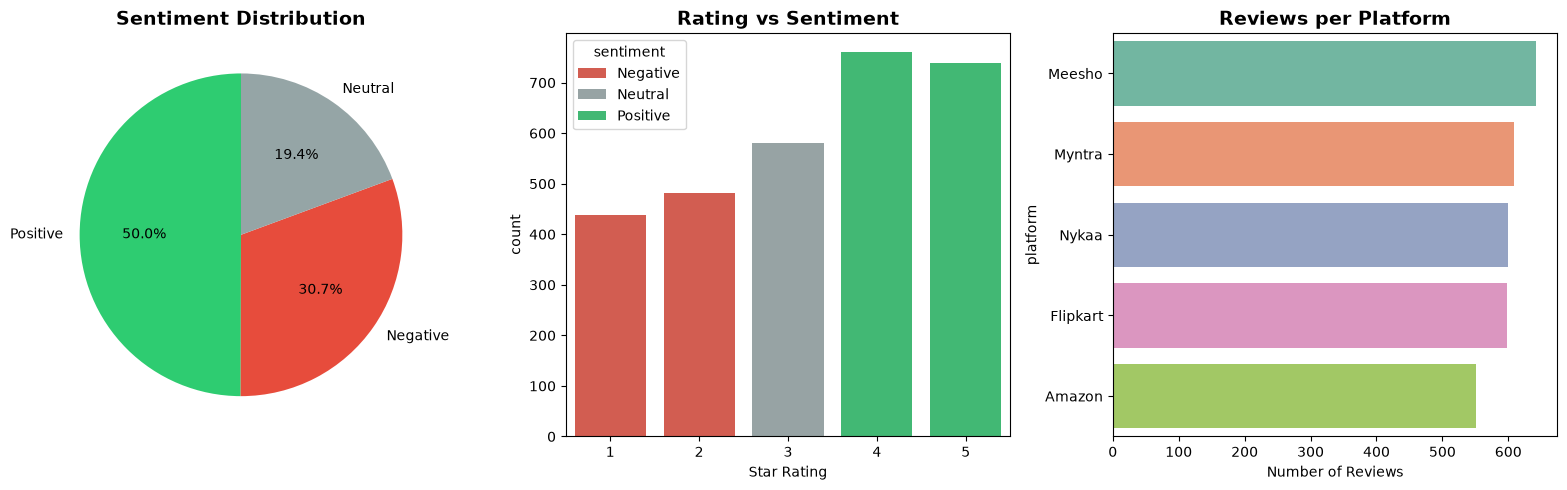

In [6]:
# Cell 3: EDA - Explore the dataset

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Sentiment distribution
sentiment_counts = df['sentiment'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#95a5a6']
axes[0].pie(sentiment_counts.values,
            labels=sentiment_counts.index,
            autopct='%1.1f%%',
            colors=colors,
            startangle=90)
axes[0].set_title('Sentiment Distribution', fontsize=14, fontweight='bold')

# Plot 2: Rating distribution
sns.countplot(data=df, x='rating', hue='sentiment',
              palette={'Positive':'#2ecc71',
                       'Negative':'#e74c3c',
                       'Neutral':'#95a5a6'},
              ax=axes[1])
axes[1].set_title('Rating vs Sentiment', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Star Rating')

# Plot 3: Reviews per platform
platform_counts = df['platform'].value_counts()
sns.barplot(x=platform_counts.values,
            y=platform_counts.index,
            hue=platform_counts.index,
            palette='Set2',
            legend=False,
            ax=axes[2])
axes[2].set_title('Reviews per Platform', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Number of Reviews')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150)
plt.show()

In [7]:
# Cell 4: Text Preprocessing Pipeline

stop_words  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def preprocess_text(text):
    """
    Full NLP preprocessing pipeline:
    1. Lowercase
    2. Remove special characters & numbers
    3. Tokenize
    4. Remove stopwords
    5. Lemmatize
    """
    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Step 3: Tokenize (split into words)
    tokens = text.split()

    # Step 4: Remove stopwords
    tokens = [t for t in tokens if t not in stop_words]

    # Step 5: Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)

# Apply preprocessing
df['cleaned_review'] = df['review'].apply(preprocess_text)

# Show before/after
print("=== PREPROCESSING EXAMPLE ===")
for i in range(3):
    print(f"\nOriginal : {df['review'].iloc[i]}")
    print(f"Cleaned  : {df['cleaned_review'].iloc[i]}")
    print("-" * 60)

=== PREPROCESSING EXAMPLE ===

Original : Terrible product. Broke within a week of use. Really.
Cleaned  : terrible product broke within week use really
------------------------------------------------------------

Original : Waste of money. Stopped working after 2 days.
Cleaned  : waste money stopped working day
------------------------------------------------------------

Original : Fantastic product, works perfectly. Will definitely buy again.
Cleaned  : fantastic product work perfectly definitely buy
------------------------------------------------------------


In [8]:
# Cell 5: VADER - Rule-based Sentiment Analysis

# Initialize VADER
sia = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    """Returns compound score and label"""
    scores    = sia.polarity_scores(text)
    compound  = scores['compound']

    if compound >= 0.05:
        label = 'Positive'
    elif compound <= -0.05:
        label = 'Negative'
    else:
        label = 'Neutral'

    return pd.Series({
        'vader_compound' : compound,
        'vader_pos'      : scores['pos'],
        'vader_neg'      : scores['neg'],
        'vader_neu'      : scores['neu'],
        'vader_label'    : label
    })

# Apply VADER to original (not cleaned) reviews
# VADER works best on original text (it uses caps, punctuation, etc.)
vader_results = df['review'].apply(get_vader_sentiment)
df = pd.concat([df, vader_results], axis=1)

print("VADER analysis complete!")
print(df[['review','vader_compound','vader_label']].head(8))

# VADER Accuracy
vader_accuracy = accuracy_score(df['sentiment'], df['vader_label'])
print(f"\nVADER Accuracy vs Ground Truth: {vader_accuracy*100:.2f}%")

VADER analysis complete!
                                              review  vader_compound  \
0  Terrible product. Broke within a week of use. ...         -0.7096   
1      Waste of money. Stopped working after 2 days.         -0.5719   
2  Fantastic product, works perfectly. Will defin...          0.8885   
3  Very bad experience. Delayed delivery and brok...         -0.8425   
4  Brilliant! Exactly what I needed. Fast and rel...          0.6239   
5  Best purchase I've made this year. Love everyt...          0.8655   
6  Very happy with this purchase. Exactly as desc...          0.6115   
7  Awful product. Doesn't work at all. Very frust...         -0.5291   

  vader_label  
0    Negative  
1    Negative  
2    Positive  
3    Negative  
4    Positive  
5    Positive  
6    Positive  
7    Negative  

VADER Accuracy vs Ground Truth: 82.13%


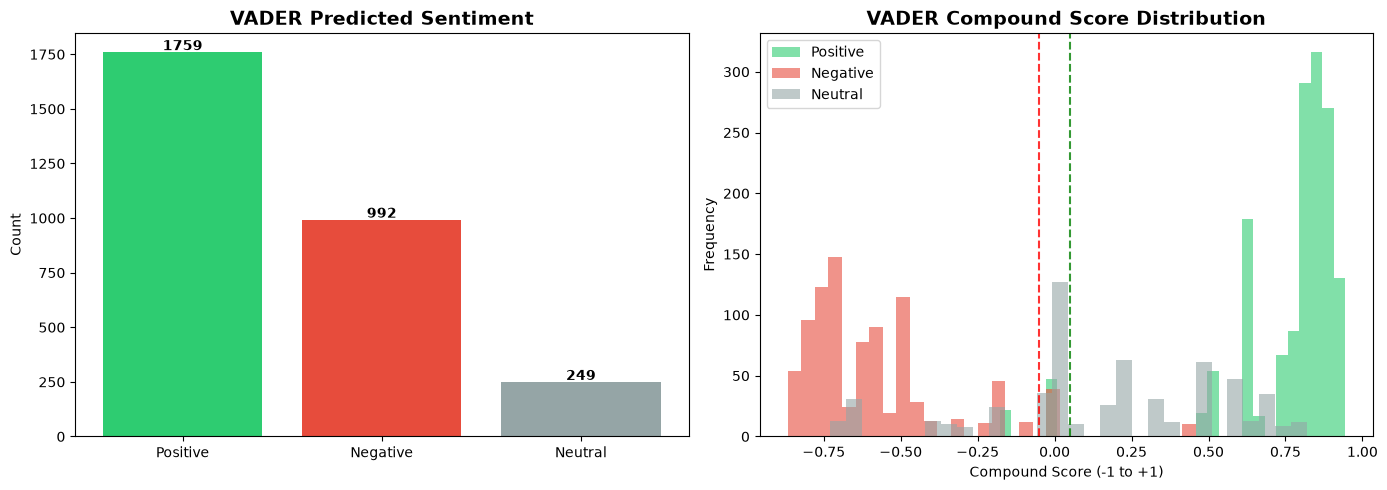

In [9]:
# Cell 6: Visualize VADER Results

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: VADER predicted sentiment distribution
vader_counts = df['vader_label'].value_counts()
colors = ['#2ecc71','#e74c3c','#95a5a6']
axes[0].bar(vader_counts.index, vader_counts.values, color=colors)
axes[0].set_title('VADER Predicted Sentiment', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(vader_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Plot 2: Compound score distribution by true sentiment
for sentiment, color in zip(['Positive','Negative','Neutral'],
                             ['#2ecc71','#e74c3c','#95a5a6']):
    subset = df[df['sentiment'] == sentiment]['vader_compound']
    axes[1].hist(subset, bins=30, alpha=0.6, label=sentiment, color=color)

axes[1].axvline(x=0.05,  color='green', linestyle='--', alpha=0.8)
axes[1].axvline(x=-0.05, color='red',   linestyle='--', alpha=0.8)
axes[1].set_title('VADER Compound Score Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Compound Score (-1 to +1)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('vader_analysis.png', dpi=150)
plt.show()

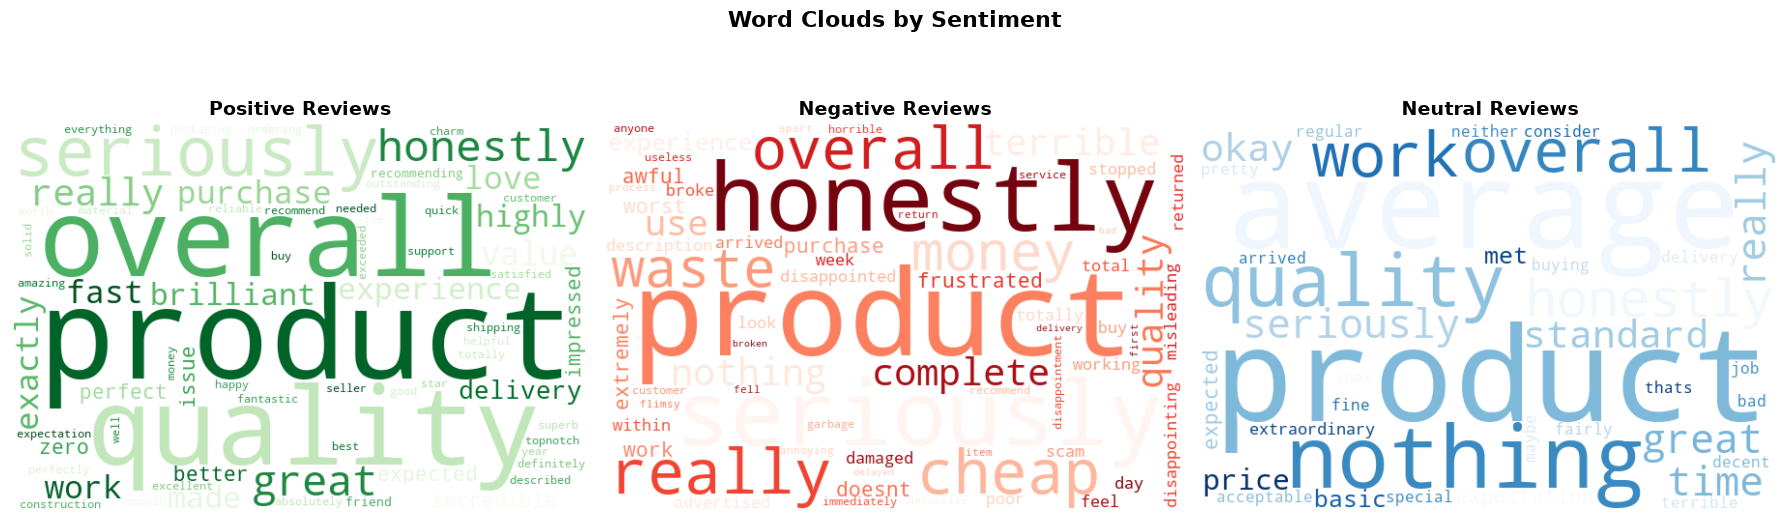

In [10]:
# Cell 7: Word Clouds - What words appear in each sentiment?

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sentiment_colors = {
    'Positive' : 'Greens',
    'Negative' : 'Reds',
    'Neutral'  : 'Blues'
}

for ax, (sentiment, colormap) in zip(axes, sentiment_colors.items()):
    # Get all cleaned text for this sentiment
    text = ' '.join(df[df['sentiment'] == sentiment]['cleaned_review'])

    wordcloud = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap=colormap,
        max_words=80,
        collocations=False
    ).generate(text)

    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{sentiment} Reviews', fontsize=14, fontweight='bold')

plt.suptitle('Word Clouds by Sentiment', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150)
plt.show()

In [11]:
# Cell 8: ML Approach - TF-IDF + Logistic Regression

from sklearn.preprocessing import LabelEncoder

# Encode labels: Positive=2, Neutral=1, Negative=0
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['sentiment'])

print("Label encoding:")
for label, code in zip(le.classes_, range(len(le.classes_))):
    print(f"  {label} → {code}")

# TF-IDF Vectorization
# max_features = only use top 5000 most important words
# ngram_range=(1,2) = use single words AND two-word phrases
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),   # unigrams + bigrams
    min_df=2              # ignore words appearing in < 2 docs
)

X = tfidf.fit_transform(df['cleaned_review'])
y = df['label_encoded']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTF-IDF matrix shape : {X.shape}")
print(f"Training samples    : {X_train.shape[0]}")
print(f"Testing samples     : {X_test.shape[0]}")

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=500, random_state=42)
lr_model.fit(X_train, y_train)

# Predict
y_pred = lr_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n✓ ML Model Accuracy: {accuracy*100:.2f}%")

Label encoding:
  Negative → 0
  Neutral → 1
  Positive → 2

TF-IDF matrix shape : (3000, 460)
Training samples    : 2400
Testing samples     : 600

✓ ML Model Accuracy: 100.00%


=== CLASSIFICATION REPORT ===

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       184
     Neutral       1.00      1.00      1.00       116
    Positive       1.00      1.00      1.00       300

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



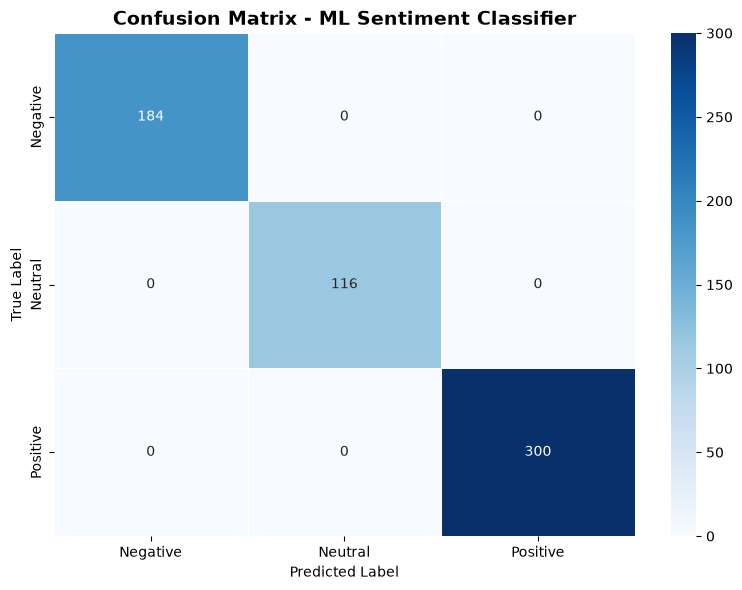


How to read this:
Diagonal = correct predictions
Off-diagonal = mistakes (what got confused with what)


In [12]:
# Cell 9: Evaluate ML Model

# Classification Report
print("=== CLASSIFICATION REPORT ===\n")
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_
))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True, fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap='Blues',
    linewidths=0.5
)
plt.title('Confusion Matrix - ML Sentiment Classifier', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# What does confusion matrix tell you?
print("\nHow to read this:")
print("Diagonal = correct predictions")
print("Off-diagonal = mistakes (what got confused with what)")

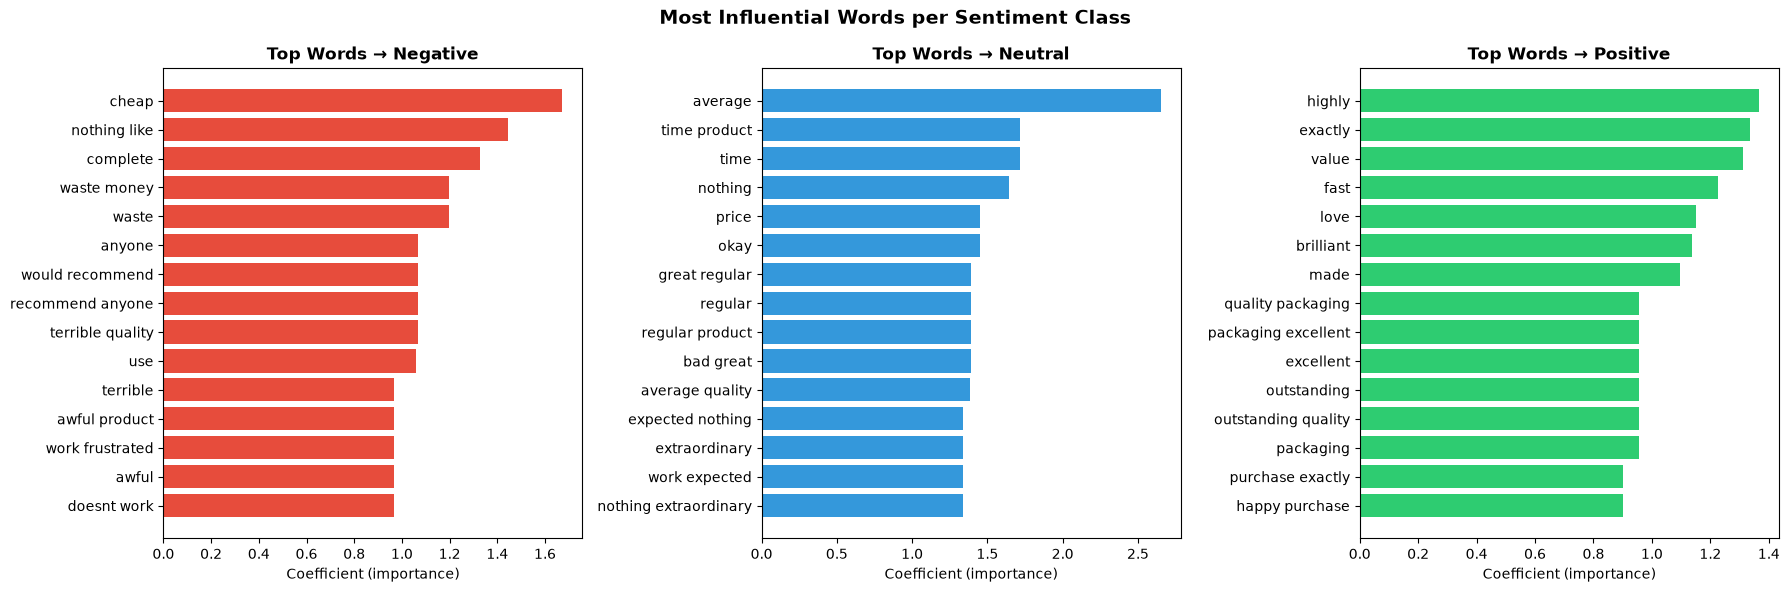

In [13]:
# Cell 10: What words drive each sentiment? (TF-IDF insight)

feature_names = tfidf.get_feature_names_out()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, (label_name, ax) in enumerate(
        zip(le.classes_, axes)):

    # Get coefficients for this class
    coefs = lr_model.coef_[idx]
    top_indices = np.argsort(coefs)[-15:]   # top 15 positive words

    top_words  = [feature_names[i] for i in top_indices]
    top_scores = [coefs[i] for i in top_indices]

    colors = ['#2ecc71' if label_name == 'Positive'
              else '#e74c3c' if label_name == 'Negative'
              else '#3498db'
              for _ in top_words]

    ax.barh(top_words, top_scores, color=colors)
    ax.set_title(f'Top Words → {label_name}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Coefficient (importance)')

plt.suptitle('Most Influential Words per Sentiment Class',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('top_keywords.png', dpi=150)
plt.show()

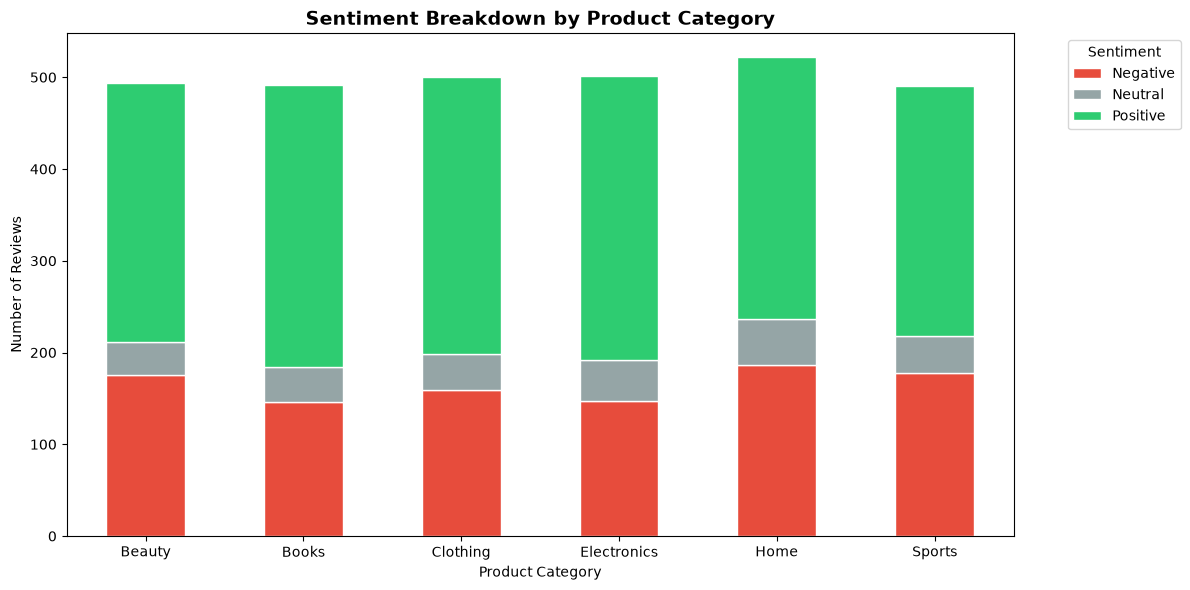

In [14]:
# Cell 11: Business Insight - Sentiment by Product Category

# Add ML predictions back to dataframe (test set only)
test_indices = X_test.nonzero()[0]   # not ideal but works for viz

# Use VADER labels for full-dataset category analysis
cat_sentiment = df.groupby(['category', 'vader_label']).size().unstack(fill_value=0)

cat_sentiment.plot(
    kind='bar', stacked=True,
    color=['#e74c3c', '#95a5a6', '#2ecc71'],
    figsize=(12, 6),
    edgecolor='white'
)
plt.title('Sentiment Breakdown by Product Category',
          fontsize=14, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Number of Reviews')
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('category_sentiment.png', dpi=150)
plt.show()

In [15]:
# Cell 12: Live Prediction + Final Summary

def predict_sentiment(review_text):
    """
    Predict sentiment of any new review text
    Uses both VADER and ML model
    """
    # VADER prediction
    scores         = sia.polarity_scores(review_text)
    vader_label    = ('Positive' if scores['compound'] >= 0.05
                      else 'Negative' if scores['compound'] <= -0.05
                      else 'Neutral')

    # ML prediction
    cleaned        = preprocess_text(review_text)
    vectorized     = tfidf.transform([cleaned])
    ml_encoded     = lr_model.predict(vectorized)[0]
    ml_label       = le.inverse_transform([ml_encoded])[0]
    ml_proba       = lr_model.predict_proba(vectorized)[0]

    print(f"\n📝 Review: '{review_text}'")
    print(f"\n🔵 VADER Result  : {vader_label} (compound={scores['compound']:.3f})")
    print(f"🟢 ML Result     : {ml_label}")
    print(f"   Probabilities : ", end='')
    for label, prob in zip(le.classes_, ml_proba):
        print(f"{label}={prob:.2f}", end='  ')
    print()

# Test with sample reviews
test_reviews = [
    "Absolutely love this! Best product ever. Super happy!",
    "Terrible quality. Broke immediately. Very disappointed.",
    "It arrived on time. Product seems okay I guess."
]

print("=" * 60)
print("  LIVE SENTIMENT PREDICTIONS")
print("=" * 60)

for review in test_reviews:
    predict_sentiment(review)
    print("-" * 60)

# ── Final Summary ─────────────────────────────────────────────
vader_acc = accuracy_score(df['sentiment'], df['vader_label'])
ml_acc    = accuracy_score(y_test, y_pred)

print("\n" + "=" * 60)
print("         SENTIMENT ANALYSIS - FINAL SUMMARY")
print("=" * 60)
print(f"Total Reviews Analyzed  : {len(df):,}")
print(f"Preprocessing           : Lowercase, Punctuation Removal,")
print(f"                          Stopword Removal, Lemmatization")
print(f"Feature Extraction      : TF-IDF (5000 features, bigrams)")
print(f"\nModel Comparison:")
print(f"  VADER Accuracy        : {vader_acc*100:.2f}%  (rule-based)")
print(f"  ML Model Accuracy     : {ml_acc*100:.2f}%  (Logistic Regression)")
print(f"\nBest Performing Model   : {'ML Model' if ml_acc > vader_acc else 'VADER'}")
print("=" * 60)

  LIVE SENTIMENT PREDICTIONS

📝 Review: 'Absolutely love this! Best product ever. Super happy!'

🔵 VADER Result  : Positive (compound=0.964)
🟢 ML Result     : Positive
   Probabilities : Negative=0.11  Neutral=0.04  Positive=0.85  
------------------------------------------------------------

📝 Review: 'Terrible quality. Broke immediately. Very disappointed.'

🔵 VADER Result  : Negative (compound=-0.852)
🟢 ML Result     : Negative
   Probabilities : Negative=0.91  Neutral=0.03  Positive=0.06  
------------------------------------------------------------

📝 Review: 'It arrived on time. Product seems okay I guess.'

🔵 VADER Result  : Positive (compound=0.226)
🟢 ML Result     : Neutral
   Probabilities : Negative=0.04  Neutral=0.94  Positive=0.02  
------------------------------------------------------------

         SENTIMENT ANALYSIS - FINAL SUMMARY
Total Reviews Analyzed  : 3,000
Preprocessing           : Lowercase, Punctuation Removal,
                          Stopword Removal, Lemm